## Transfer Learning with TensorFlow - Scaling Up

#### In this notebook we're going to scale up from using 10 classes of the [Food101](https://www.kaggle.com/datasets/dansbecker/food-101) dataset to using all (i.e., 101) of the classes in the dataset.  The Food101 dataset consists of 1000 images per class (750 of each class in the training set and 250 of each class in the test set), totalling 101000 images. And we're going to train the model on only 10% of the data  using transfer learning!

#### Preliminaries

In [1]:
!nvidia-smi

Wed Mar  5 20:40:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf

print(tf.__version__)

2.18.0


Download the `helper_functions.py` script...

In [3]:
!wget https://raw.githubusercontent.com/ROARMarketingConcepts/Tensorflow-Deep-Learning/refs/heads/main/extras/helper_functions.py

--2025-03-05 20:40:55--  https://raw.githubusercontent.com/ROARMarketingConcepts/Tensorflow-Deep-Learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10245 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.00K  --.-KB/s    in 0s      

2025-03-05 20:40:55 (110 MB/s) - ‘helper_functions.py’ saved [10245/10245]



In [4]:
from helper_functions import *

#### We will leverage pre-trained models in `tf.keras.applications` to apply to image classification use cases.

#### Let's get the data...

In [5]:
# Get 10% of the data of the 10 classes
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

# Unzip the data
unzip_data("101_food_classes_10_percent.zip")

--2025-03-05 20:42:23--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.175.207, 74.125.24.207, 142.251.10.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.175.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G  21.7MB/s    in 77s     

2025-03-05 20:43:42 (20.0 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [6]:
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/train'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/hummus'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/ravioli'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pancakes'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/apple_pie'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/escargots'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/caprese_salad'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/french_fries'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/frozen_yogurt'.
There are 0 directories and 75 images in '101_food_classe

Now we've got some image data, we need a way of loading it into a TensorFlow compatible format.

Previously, we've used the `ImageDataGenerator` class. However, as of August 2023, this class is deprecated and isn't recommended for future usage (it's too slow). Because of this, we'll move onto using `tf.keras.utils.image_dataset_from_directory()`.

This method expects image data in the following file format:

`main_directory/`

`...class_a/`

`......a_image_1.jpg`

`......a_image_2.jpg`

`...class_b/`

`......b_image_1.jpg`

`......b_image_2.jpg`



In [7]:
# Setup data inputs

train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

IMG_SIZE = (224, 224) # define image size

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical", # what type are the labels?
                                                                            batch_size=32) # batch_size is 32 by default, this is generally a good number

test_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                           image_size=IMG_SIZE,
                                                                           label_mode="categorical")

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [8]:
train_data_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>

In [9]:
train_data_10_percent.class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [10]:
# See an example batch of data.  Notice that the labels are OneHotEncoded!

for images, labels in train_data_10_percent.take(1):
  print(images, labels)

tf.Tensor(
[[[[2.41830368e+01 1.31830359e+01 1.71830349e+01]
   [2.16237240e+01 1.06237240e+01 1.46237240e+01]
   [1.98788261e+01 9.87882614e+00 1.04502544e+01]
   ...
   [1.26853745e+02 1.16710800e+02 6.11393280e+01]
   [1.35769592e+02 1.19580460e+02 5.73450890e+01]
   [1.57680267e+02 1.36217850e+02 7.05034866e+01]]

  [[1.66846313e+01 7.68463087e+00 1.06846304e+01]
   [1.64154987e+01 5.41549778e+00 9.41549778e+00]
   [1.96358433e+01 9.63584232e+00 1.06358423e+01]
   ...
   [1.64283585e+02 1.55828186e+02 1.01030006e+02]
   [1.50225174e+02 1.36109375e+02 7.48494492e+01]
   [1.15071785e+02 9.61298218e+01 3.02044315e+01]]

  [[2.17273598e+01 1.27273598e+01 1.57273598e+01]
   [2.35267868e+01 1.25267859e+01 1.65267868e+01]
   [2.26728306e+01 1.26728315e+01 1.36728315e+01]
   ...
   [1.68371109e+02 1.61636063e+02 1.07726601e+02]
   [1.76504150e+02 1.66128479e+02 1.04837334e+02]
   [1.33516922e+02 1.18297821e+02 5.43468590e+01]]

  ...

  [[2.76336670e+00 4.00000000e+00 0.00000000e+00]
   [2

#### ModelCheckPoint

Recall that the `ModelCheckpoint` callback gives us the ability to save the model, as a whole in the `SavedModel` format or the weights (patterns) only to a specified directory as it trains.

For example, say we fit a feature extraction transfer learning model for 5 epochs and we check the training curves and see it was still improving and we want to see if fine-tuning for another 5 epochs could help, we can load the checkpoint, unfreeze some (or all) of the base model layers and then continue training.

Let's create a `ModelCheckpoint` callback. To do so, we have to specify a directory to which we would like to save.

In [11]:
# Setup checkpoint path
checkpoint_path = "101_classes_model_checkpoints_weights/.weights.h5" # note: remember saving directly to Colab is temporary

# Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True, # set to False to save the entire model
                                                         save_best_only=True, # save only the best model weights instead of a model every epoch
                                                         save_freq="epoch", # save every epoch
                                                         verbose=1)

Checkpoint ready. Now let's create a small data augmentation model with the Sequential API. Because we're working with a reduced sized training set, this will help prevent our model from overfitting on the training data.

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# from tensorflow.keras.layers.experimental import preprocessing

# NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomHeight(0.2),
  layers.RandomWidth(0.2),
  # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNetV2B0
  ], name ="data_augmentation")

#### Build the first model, `model`.

In [13]:
# Set up input shape and base model, freezing the base model layers
input_shape = (224, 224, 3)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

# Create input layer
inputs = layers.Input(shape=input_shape, name="input_layer")

# Add in data augmentation Sequential model as a layer
x = data_augmentation(inputs)

# Give base_model inputs (after augmentation) and don't train it
x = base_model(x, training=False)

# Pool output features of base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Put a dense layer on as the output
outputs = layers.Dense(len(train_data_10_percent.class_names), activation="softmax", name="output_layer")(x)

# Make a model with inputs and outputs
model = keras.Model(inputs, outputs)

# Compile the model
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-b0 (Functional)       │ (None, None, None, 1280)    │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling_layer         │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 101)                 │         129,381 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,048,693 (23.07 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [18]:
# Fit the model
history = model.fit(train_data_10_percent,
                    epochs=5,
                    steps_per_epoch=len(train_data_10_percent),
                    validation_data=test_data_10_percent,
                    validation_steps=int(0.25* len(test_data_10_percent)), # validate for less steps
                    # Track model training logs
                    callbacks=[create_tensorboard_callback("transfer_learning_scaling_up", "10_percent_data_aug")])


Saving TensorBoard log files to: transfer_learning_scaling_up/10_percent_data_aug/20250305-211022
Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 103s 358ms/step - accuracy: 0.1248 - loss: 4.1009 - val_accuracy: 0.4196 - val_loss: 2.5678
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 121s 288ms/step - accuracy: 0.4149 - loss: 2.6287 - val_accuracy: 0.4954 - val_loss: 2.0677
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 62s 260ms/step - accuracy: 0.4898 - loss: 2.1910 - val_accuracy: 0.5328 - val_loss: 1.8522
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - accuracy: 0.5191 - loss: 1.9921 - val_accuracy: 0.5441 - val_loss: 1.7502
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 82s 346ms/step - accuracy: 0.5512 - loss: 1.8259 - val_accuracy: 0.5622 - val_loss: 1.6731


In [20]:
# Evaluate model on entire test dataset
results_feature_extraction_model = model.evaluate(test_data_10_percent)
results_feature_extraction_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.5672 - loss: 1.6577


[1.6436759233474731, 0.5706534385681152]

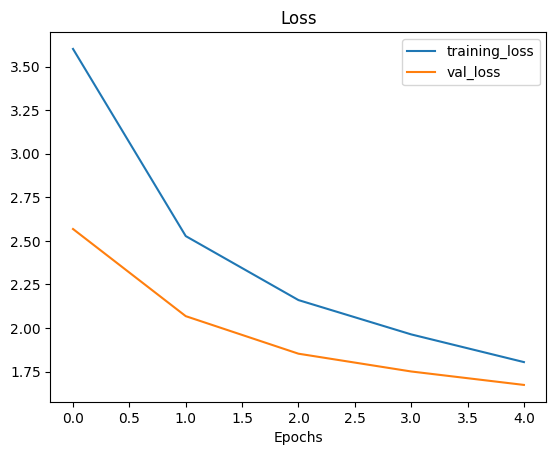

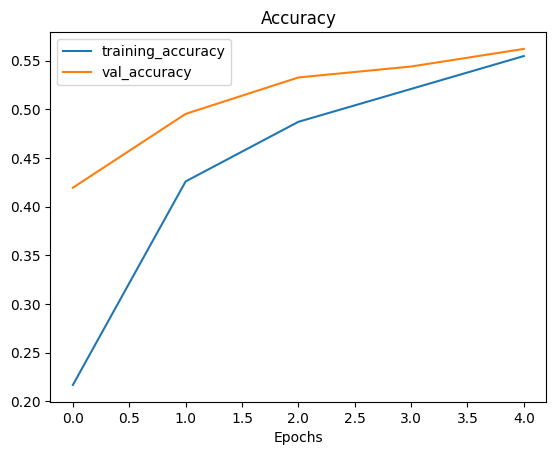

In [21]:
# Check out our model's training curves
plot_loss_curves(history)

I am right here...

Let's begin by downloading the data for experiment 1, using feature extraction transfer learning on 1% of the training data with data augmentation.

In [ ]:
# Download and unzip data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
unzip_data("10_food_classes_1_percent.zip")

# Create training and test dirs
train_dir_1_percent = "10_food_classes_1_percent/train/"
test_dir = "10_food_classes_1_percent/test/"

# Walk through 1 percent data directory and list number of files
walk_through_dir("10_food_classes_1_percent")

--2025-03-05 14:52:18--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.251.2.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133612354 (127M) [application/zip]
Saving to: ‘10_food_classes_1_percent.zip’

10_food_classes_1_p 100%[===================>] 127.42M   198MB/s    in 0.6s    

2025-03-05 14:52:19 (198 MB/s) - ‘10_food_classes_1_percent.zip’ saved [133612354/133612354]

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/train'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/sushi'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ramen'.
There are 0 directories and 7 images in '10_food_classes_1_pe

In [ ]:
IMG_SIZE = (224, 224)

train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_1_percent,
                                                                           label_mode="categorical",
                                                                           batch_size=32, # default
                                                                           image_size=IMG_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


#### Adding data augmentation right into the model

Previously we've used the different parameters of the ImageDataGenerator class to augment our training images, this time we're going to build data augmentation right into the model.

How?

Using the tf.keras.layers module and creating a dedicated data augmentation layer.

This a relatively new feature added to TensorFlow 2.10+ but it's very powerful. Adding a data augmentation layer to the model has the following benefits:

Preprocessing of the images (augmenting them) happens on the GPU rather than on the CPU (much faster).
Images are best preprocessed on the GPU where as text and structured data are more suited to be preprocessed on the CPU.
Image data augmentation only happens during training so we can still export our whole model and use it elsewhere. And if someone else wanted to train the same model as us, including the same kind of data augmentation, they could.


To use data augmentation right within our model we'll create a Keras Sequential model consisting of only data preprocessing layers, we can then use this Sequential model within another Functional model.

The data augmentation transformations we're going to use are:

* `tf.keras.layers.RandomFlip` - **flips** image on horizontal or vertical axis.
* `tf.keras.layersRandomRotation` - **randomly rotates** image by a specified amount.
* `tf.keras.layers.RandomZoom` - **randomly zooms** into an image by specified amount.
* `tf.keras.layers.RandomHeight` - **randomly shifts image height** by a specified amount.
* `tf.keras.layers.RandomWidth` - **randomly shifts image width** by a specified amount.
* `tf.keras.layers.Rescaling` - **normalizes the image pixel values to be between 0 and 1**, this is worth mentioning because it is required for some image models but since we're using `tf.keras.applications.efficientnet_v2.EfficientNetV2B0`, it's not required (the model pretrained model implements rescaling itself).

#### The benefits of data augmentation inside the model are as follows:

* Preprocessing of images (i.e., augmenting them) happens on the GPU rather than the CPU.
* Image augmentation only happens during training (not during inference), so we can still export the model and use it elsewhere.

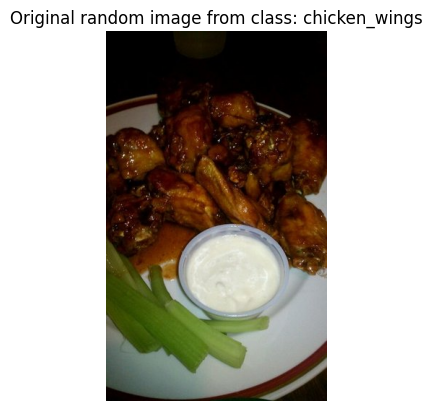

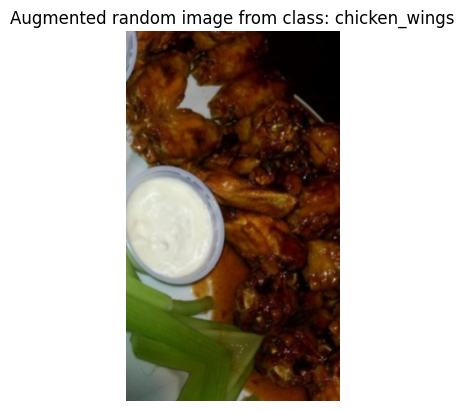

In [ ]:
# View a random image
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg
# import os
# import random
# target_class = random.choice(train_data_1_percent.class_names) # choose a random class
# target_dir = "10_food_classes_1_percent/train/" + target_class # create the target directory
# random_image = random.choice(os.listdir(target_dir)) # choose a random image from target directory
# random_image_path = target_dir + "/" + random_image # create the choosen random image path

# # Plot the random image (original)
# img = mpimg.imread(random_image_path) # read in the chosen target image
# plt.imshow(img) # plot the target image
# plt.title(f"Original random image from class: {target_class}")
# plt.axis(False); # turn off the axes

# # Augment the image
# augmented_img = data_augmentation(img, training=True)
# plt.figure()
# plt.imshow(augmented_img/255.) # requires normalization after augmentation
# plt.title(f"Augmented random image from class: {target_class}")
# plt.axis(False);

## **Model 1:** Feature extraction transfer learning on 1% of the data with data augmentation

Set up input shape and base model, freezing the base model layers.

In [ ]:
model_1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-b0 (Functional)       │ (None, None, None, 1280)    │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling_layer         │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │          12,810 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,957,744 (22.73 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 25,622 (100.09 KB)

The important thing to remember is **data augmentation only runs during training**. So if we were to evaluate or use our model for inference (predicting the class of an image) the **data augmentation layers will be automatically turned off**.

To see this in action, let's evaluate our model on the test data.

In [ ]:
# Evaluate on the test data
results_1_percent_data_aug = model_1.evaluate(test_data)
results_1_percent_data_aug

79/79 ━━━━━━━━━━━━━━━━━━━━ 77s 969ms/step - accuracy: 0.3477 - loss: 1.9683


[1.9586714506149292, 0.3431999981403351]

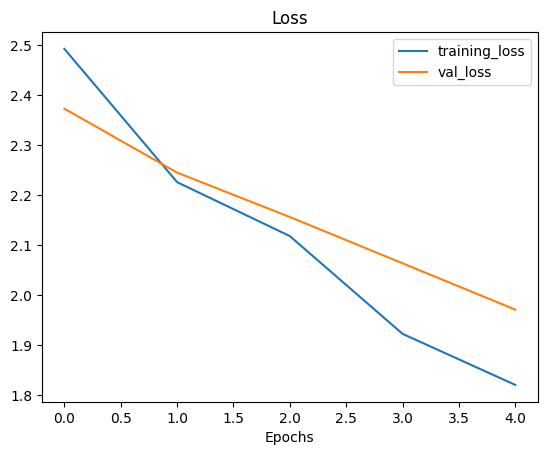

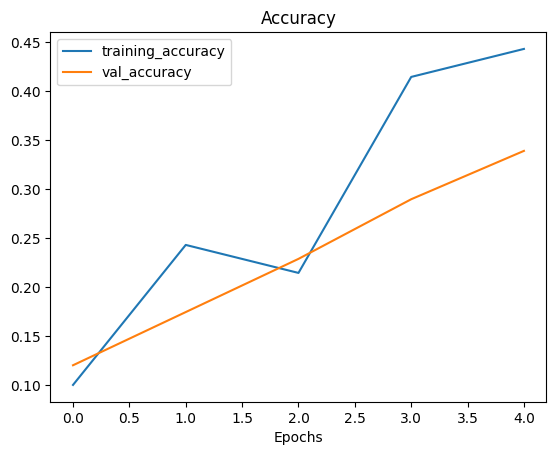

In [ ]:
# How does the model go with a data augmentation layer with 1% of data
plot_loss_curves(history_model_1)

## **Model 2:** Feature extraction transfer learning with 10% of data and data augmentation

For this model run, we're going to introduce a new callback, the `ModelCheckpoint` callback.

The `ModelCheckpoint` callback gives us the ability to save the model, as a whole in the `SavedModel` format or the weights (patterns) only to a specified directory as it trains.

For example, say we fit a feature extraction transfer learning model for 5 epochs and we check the training curves and see it was still improving and we want to see if fine-tuning for another 5 epochs could help, we can load the checkpoint, unfreeze some (or all) of the base model layers and then continue training.

Let's create a `ModelCheckpoint` callback. To do so, we have to specify a directory to which we would like to save.

In [ ]:
# Setup checkpoint path
checkpoint_path = "ten_percent_model_checkpoints_weights/.weights.h5" # note: remember saving directly to Colab is temporary

# Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True, # set to False to save the entire model
                                                         save_best_only=True, # save only the best model weights instead of a model every epoch
                                                         save_freq="epoch", # save every epoch
                                                         verbose=1)

In [ ]:
# Download and unzip data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
unzip_data("10_food_classes_10_percent.zip")

# Create training and test dirs
train_dir_10_percent = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

# Walk through 1 percent data directory and list number of files
walk_through_dir("10_food_classes_10_percent")

--2025-03-05 15:23:26--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 142.250.141.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip.3’

10_food_classes_10_ 100%[===================>] 160.74M   159MB/s    in 1.0s    

2025-03-05 15:23:28 (159 MB/s) - ‘10_food_classes_10_percent.zip.3’ saved [168546183/168546183]

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_

In [ ]:
IMG_SIZE = (224, 224)

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_10_percent,
                                                                           label_mode="categorical",
                                                                           batch_size=32, # default
                                                                           image_size=IMG_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [ ]:
# NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomHeight(0.2),
  layers.RandomWidth(0.2),
  # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNetV2B0
  ], name ="data_augmentation")

In [ ]:
# Set up input shape and base model, freezing the base model layers
input_shape = (224, 224, 3)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

# Create input layer
inputs = layers.Input(shape=input_shape, name="input_layer")

# Add in data augmentation Sequential model as a layer
x = data_augmentation(inputs)

# Give base_model inputs (after augmentation) and don't train it
x = base_model(x, training=False)

# Pool output features of base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Put a dense layer on as the output
outputs = layers.Dense(10, activation="softmax", name="output_layer")(x)

# Make a model with inputs and outputs
model_2 = keras.Model(inputs, outputs)

# Compile the model
model_2.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_model_2 = model_2.fit(train_data_10_percent,
                    epochs=5,
                    steps_per_epoch=len(train_data_10_percent),
                    validation_data=test_data,
                    validation_steps=int(0.25* len(test_data)), # validate for less steps
                    # Track model training logs
                    callbacks=[
                        create_tensorboard_callback("transfer_learning", "10_percent_data_aug"),
                        checkpoint_callback
                        ]
                    )

Saving TensorBoard log files to: transfer_learning/10_percent_data_aug/20250305-152333
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1967 - loss: 2.2017
Epoch 1: val_loss improved from inf to 1.51530, saving model to ten_percent_model_checkpoints_weights/.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.2010 - loss: 2.1949 - val_accuracy: 0.6612 - val_loss: 1.5153
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6211 - loss: 1.5435
Epoch 2: val_loss improved from 1.51530 to 1.09397, saving model to ten_percent_model_checkpoints_weights/.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6215 - loss: 1.5399 - val_accuracy: 0.7730 - val_loss: 1.0940
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7601 - loss: 1.1302
Epoch 3: val_loss improved from 1.09397 to 0.92116, saving model to ten_percent_model_checkpoints_weights/.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.7588 - loss: 1.1309 - val_accuracy

#### Let's put the code in the previous cell into a function `create_base_model()` since we'll be running it quite a few times.

In [ ]:
def create_base_model(input_shape: tuple[int, int, int] = (224, 224, 3),
                      output_shape: int = 10,
                      learning_rate: float = 0.001,
                      training: bool = False) -> tf.keras.Model:
    """
    Create a model based on EfficientNetV2B0 with built-in data augmentation.

    Parameters:
    - input_shape (tuple): Expected shape of input images. Default is (224, 224, 3).
    - output_shape (int): Number of classes for the output layer. Default is 10.
    - learning_rate (float): Learning rate for the Adam optimizer. Default is 0.001.
    - training (bool): Whether the base model is trainable. Default is False.

    Returns:
    - tf.keras.Model: The compiled model with specified input and output settings.
    """

    # Create base model
    base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
    base_model.trainable = training

    # Setup model input and outputs with data augmentation built-in
    inputs = layers.Input(shape=input_shape, name="input_layer")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # pass augmented images to base model but keep it in inference mode
    x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
    outputs = layers.Dense(units=output_shape, activation="softmax", name="output_layer")(x)
    model = tf.keras.Model(inputs, outputs)

    # Compile model
    model.compile(loss="categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=["accuracy"])

    return model

# Create an instance of model_2 with our new function
model_2 = create_base_model()

In [ ]:
model_2.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-b0 (Functional)       │ (None, None, None, 1280)    │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling_layer         │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │          12,810 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,957,744 (22.73 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 25,622 (100.09 KB)

In [ ]:
results_10_percent_data_aug = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 78s 989ms/step - accuracy: 0.8452 - loss: 0.6731


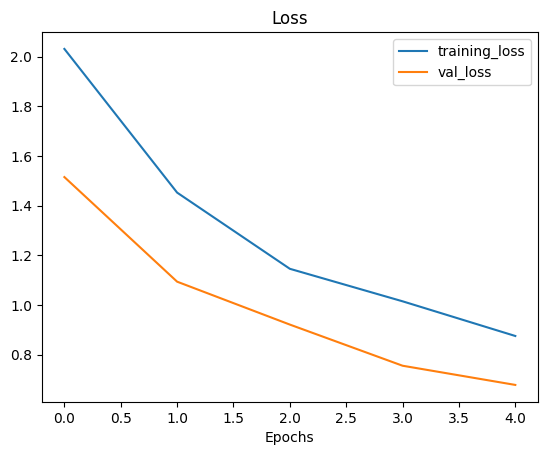

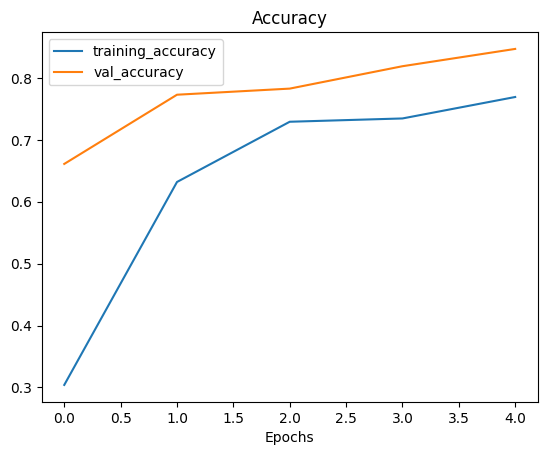

In [ ]:
# How does the model go with a data augmentation layer with 10% of data
plot_loss_curves(history_model_2)

Since we saved the model's weights at various checkpoints, we might as well see what it's like to load it back in. We'll be able to test if it saved correctly by evaluting it on the test data.

To load saved model weights you can use the the load_weights() method, passing it the path where your saved weights are stored.

In [ ]:
# Load in saved model weights and evaluate model
model_2.load_weights(checkpoint_path)
loaded_weights_model_results = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8413 - loss: 0.6848


In [ ]:
# If the results from the native model and the loaded weights are the same, this should output True
results_10_percent_data_aug == loaded_weights_model_results

False

In [ ]:
import numpy as np
# Check to see if loaded model results are very close to native model results (should output True)
np.isclose(np.array(results_10_percent_data_aug), np.array(loaded_weights_model_results))

array([ True,  True])

In [ ]:
# Check the difference between the two results (small values)
print(np.array(results_10_percent_data_aug) - np.array(loaded_weights_model_results))

[-1.1920929e-07  0.0000000e+00]


## **Model 3:** Fine-tune an existing model on 10% of the data

#### Our existing model is `model_2`.

1. Unfreeze the entire model_2_base_model by setting its trainable attribute to `True`.

2. Refreeze every layer in model_2_base_model except for the last 10 by looping through them and setting their trainable attribute to `False`.

3. Recompile the whole model.

In [ ]:
# Make all the layers in model_2_base_model trainable
base_model.trainable = True

# Freeze all layers except for the last 10
for layer in base_model.layers[:-10]:
  layer.trainable = False

# Recompile the whole model (always recompile after any adjustments to a model)
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr is 10x lower than before for fine-tuning
                metrics=["accuracy"])

In [ ]:
#  Check which layers are tuneable (trainable)

for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_5 False
1 rescaling_3 False
2 normalization_3 False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dw

Get count of trainable variables.  The model has a total of 12 trainable variables, which include the last 10 layers of the base model and the weight and bias parameters of the Dense output layer.

In [ ]:
print(len(model_2.trainable_variables))

12


In [ ]:
# Fine tune for another 5 epochs

initial_epochs = 5
fine_tune_epochs = initial_epochs + 5

# Refit the model (same as model_2 except with more trainable layers)
history_model_3 = model_2.fit(train_data_10_percent,
                                               epochs=fine_tune_epochs,
                                               validation_data=test_data,
                                               initial_epoch=history_model_2.epoch[-1], # start from previous last epoch
                                               validation_steps=int(0.25 * len(test_data)),
                                               callbacks=[create_tensorboard_callback("transfer_learning", "10_percent_fine_tune_last_10")]) # name experiment appropriately


Saving TensorBoard log files to: transfer_learning/10_percent_fine_tune_last_10/20250305-153400
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7773 - loss: 1.0204 - val_accuracy: 0.8289 - val_loss: 0.7480
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7862 - loss: 0.8812 - val_accuracy: 0.8405 - val_loss: 0.6517
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 143s 5s/step - accuracy: 0.8049 - loss: 0.7984 - val_accuracy: 0.8536 - val_loss: 0.6103
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 141s 5s/step - accuracy: 0.8202 - loss: 0.7686 - val_accuracy: 0.8602 - val_loss: 0.5689
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8402 - loss: 0.7271 - val_accuracy: 0.8717 - val_loss: 0.5278
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.8033 - loss: 0.7472 - val_accuracy: 0.8635 - val_loss: 0.5074


In [ ]:
# Evaluate the model on the test data
results_fine_tune_10_percent = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 78s 991ms/step - accuracy: 0.8593 - loss: 0.5143


In [ ]:
def compare_histories(original_history, new_history, initial_epochs=5):
    """
    Compares two model history objects.
    """
    # Get original history measurements
    acc = original_history.history["accuracy"]
    loss = original_history.history["loss"]

    print(len(acc))

    val_acc = original_history.history["val_accuracy"]
    val_loss = original_history.history["val_loss"]

    # Combine original history with new history
    total_acc = acc + new_history.history["accuracy"]
    total_loss = loss + new_history.history["loss"]

    total_val_acc = val_acc + new_history.history["val_accuracy"]
    total_val_loss = val_loss + new_history.history["val_loss"]

    print(len(total_acc))
    print(total_acc)

    # Make plots
    plt.figure(figsize=(8, 8))
    plt.subplot(2, 1, 1)
    plt.plot(total_acc, label='Training Accuracy')
    plt.plot(total_val_acc, label='Validation Accuracy')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 1, 2)
    plt.plot(total_loss, label='Training Loss')
    plt.plot(total_val_loss, label='Validation Loss')
    plt.plot([initial_epochs-1, initial_epochs-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('epoch')
    plt.show()


5
11
[0.30399999022483826, 0.6320000290870667, 0.7293333411216736, 0.734666645526886, 0.7693333625793457, 0.7666666507720947, 0.7839999794960022, 0.8013333082199097, 0.8133333325386047, 0.8346666693687439, 0.8013333082199097]


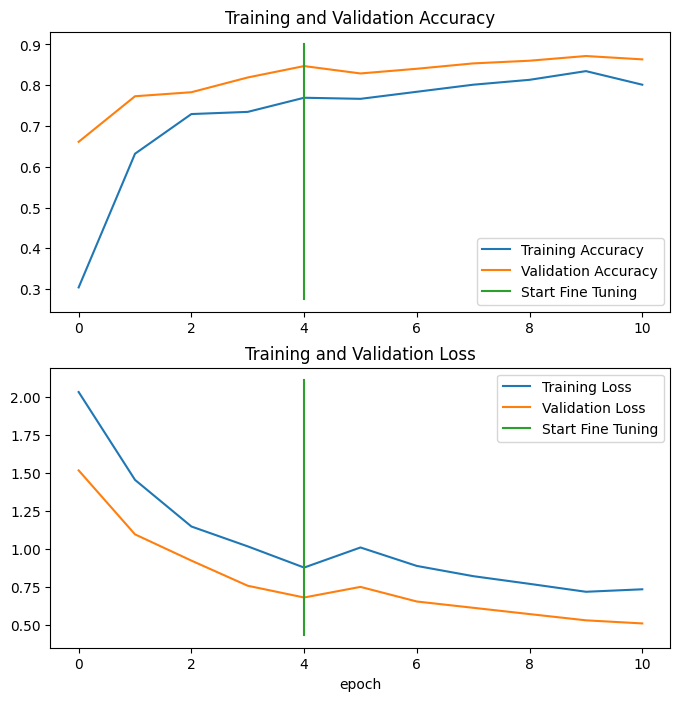

In [ ]:
compare_histories(history_model_2, history_model_3)

## **Model 4:** Fine-tune an existing model all of the data

In [ ]:
# Download and unzip 10 classes of data with all images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
unzip_data("10_food_classes_all_data.zip")

# Setup data directories
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"


--2025-03-05 15:57:23--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 142.250.141.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M   119MB/s    in 3.7s    

2025-03-05 15:57:27 (134 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [ ]:
# How many images are we working with now?
walk_through_dir("10_food_classes_all_data")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/train'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/steak'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'.

In [ ]:
# Setup data inputs
import tensorflow as tf
IMG_SIZE = (224, 224)

train_data_10_classes_full = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                                 label_mode="categorical",
                                                                                 image_size=IMG_SIZE)

# Note: this is the same test dataset we've been using for the previous modelling experiments
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 7500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [ ]:
# Evaluate model (this is the fine-tuned 10 percent of data version)
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8480 - loss: 0.5283


[0.5257102847099304, 0.8503999710083008]

In [ ]:
results_fine_tune_10_percent

[0.52571040391922, 0.8503999710083008]

To keep our experiments clean, we'll load a create a new instance of `model_2` using our `create_base_model()` function.

More specifically, we're trying to measure:

* **Experiment 3 (previous one**) - `model_2` with 10 layers fine-tuned for 5 more epochs on 10% of the data.
* **Experiment 4 (this one)** - `model_2` with layers fined-tuned for 5 more epochs on 100% on the data.

Importantly, both experiments should use the same test data (to keep evaluation the same).

And they should also start from the same checkpoint (model_2 feature extractor trained for 5 epochs on 10% of the data).

In [ ]:
# Create a new instance of model_2 for Experiment 4
model_2 = create_base_model(learning_rate=0.0001) # 10x lower learning rate for fine-tuning

In [ ]:
# Load previously checkpointed weights
model_2.load_weights(checkpoint_path)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model_2.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-b0 (Functional)       │ (None, None, None, 1280)    │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling_layer         │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 10)                  │          12,810 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
print(len(model_2.trainable_variables))

2


In [ ]:
# After loading the weights, this should have gone down (no fine-tuning)
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 84s 996ms/step - accuracy: 0.8379 - loss: 0.6830


[0.6811602711677551, 0.8348000049591064]

#### Okay, so what have we done so far?  

1. Trained a feature extraction transfer learning model for 5 epochs on 10% of the data (with all base model layers frozen) and saved the model's weights using ModelCheckpoint **(Model 2)**.
2. Fine-tuned the same model on the same 10% of the data for a further 5 epochs with the top 10 layers of the base model unfrozen **(Model 3)**.
Saved the results and training logs each time.
3. Reloaded the model from 1 to do the same steps as 2 but with all (100%) of the data **(Model 4)**. However, we're going to fine-tune the last 10 layers of the base model with the full dataset for another 5 epochs.

But first let's remind ourselves which layers are trainable:

In [ ]:
# Check which layers are tuneable in the whole model
for layer_number, layer in enumerate(model_2.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer True
1 data_augmentation True
2 efficientnetv2-b0 False
3 global_average_pooling_layer True
4 output_layer True


Remember, the base_model of `model_2` (`efficientnetv2-b0`) can be referenced by `model_2.layers[2]`.

So let's unfreeze the last 10 layers of the base_model to make them trainable (for fine-tuning).

In [ ]:
# Unfreeze the top 10 layers in model_2's base_model
model_2_base_model = model_2.layers[2]
model_2_base_model.trainable = True

# Freeze all layers except for the last 10
for layer in model_2_base_model.layers[:-10]:
  layer.trainable = False

In [ ]:
# Check which layers are tuneable in the base model
for layer_number, layer in enumerate(model_2_base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer_8 False
1 rescaling_5 False
2 normalization_5 False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dw

In [ ]:
# Recompile the model (always recompile after any adjustments to a model)

model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr is 10x lower than before for fine-tuning
                metrics=["accuracy"])

In [ ]:
# Continue to train and fine-tune the model to our data
fine_tune_epochs = initial_epochs + 5

history_model_4 = model_2.fit(train_data_10_classes_full,
                                           epochs=fine_tune_epochs,
                                           initial_epoch=history_model_2.epoch[-1],
                                           validation_data=test_data,
                                           validation_steps=int(0.25 * len(test_data)),
                                           callbacks=[create_tensorboard_callback("transfer_learning", "full_10_classes_fine_tune_last_10")])


Saving TensorBoard log files to: transfer_learning/full_10_classes_fine_tune_last_10/20250305-184252
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.7041 - loss: 1.0482 - val_accuracy: 0.8454 - val_loss: 0.4781
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.7703 - loss: 0.7727 - val_accuracy: 0.8701 - val_loss: 0.3776
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.7831 - loss: 0.6861 - val_accuracy: 0.8783 - val_loss: 0.3513
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.8145 - loss: 0.6126 - val_accuracy: 0.8997 - val_loss: 0.2930
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.8248 - loss: 0.5817 - val_accuracy: 0.9013 - val_loss: 0.2665
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.8308 - loss: 0.5551 - val_accuracy: 0.9046 - val_loss: 0.2432


Let's evaluate on all of the test data.

In [ ]:
results_fine_tune_full_data = model_2.evaluate(test_data)
results_fine_tune_full_data

79/79 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9118 - loss: 0.2562


[0.2626070976257324, 0.9128000140190125]

Compare with results_fine_tune_10_percent

In [ ]:
results_fine_tune_10_percent

[0.52571040391922, 0.8503999710083008]

5
11
[0.30399999022483826, 0.6320000290870667, 0.7293333411216736, 0.734666645526886, 0.7693333625793457, 0.7350666522979736, 0.7803999781608582, 0.7957333326339722, 0.8154666423797607, 0.8223999738693237, 0.8341333270072937]


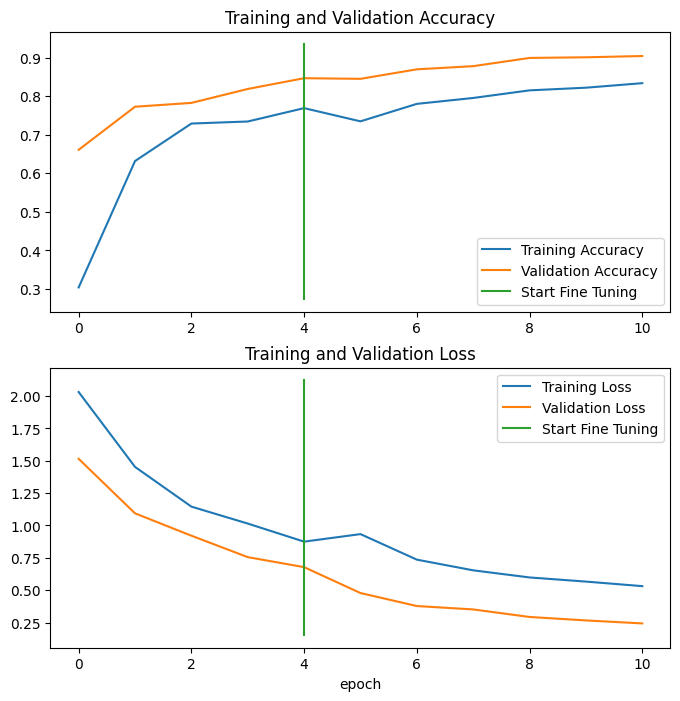

In [ ]:
# How did fine-tuning go with more data?
compare_histories(original_history=history_model_2,
                 new_history=history_model_4,
                 initial_epochs=5)
